In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense

# random seed so output does not jump too much
np.random.seed(42)
tf.random.set_seed(42)



In [14]:
# xor data (inputs and target)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

print("X:\n", X)
print("y:\n", y)

X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y:
 [[0.]
 [1.]
 [1.]
 [0.]]


In [15]:
model = keras.Sequential([
    Dense(8, activation="relu", input_shape=(2,)),
    Dense(1, activation="sigmoid")
])

opt = keras.optimizers.SGD(learning_rate=0.1) 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer=opt, loss="mse")

In [17]:
class LRCallback(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.learning_rates = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        lr = float(tf.keras.backend.get_value(lr))
        self.learning_rates.append(lr)

In [18]:
Converged = False
Target_loss = 0.001
Losses = []
Learning_rates = []

max_epochs = 5000
epoch = 0

check_every = 10

while (not Converged) and (epoch < max_epochs):
    lr_cb = LRCallback()
    hist = model.fit(
        X, y,
        epochs=min(check_every, max_epochs - epoch),
        verbose=0,
        callbacks=[lr_cb]
    )

    chunk_losses = hist.history["loss"]  # MSE per epoch
    Losses.extend(chunk_losses)

    if lr_cb.learning_rates:
        Learning_rates.extend(lr_cb.learning_rates)
    else:
        current_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
        Learning_rates.extend([current_lr] * len(chunk_losses))

    epoch += len(chunk_losses)
    Converged = Losses[-1] <= Target_loss

print(f"Converged={Converged}")
print(f"Target_loss={Target_loss}")
print(f"Final loss={Losses[-1]:.6f}")
print(f"Epochs trained={epoch}")


Converged=False
Target_loss=0.001
Final loss=0.001321
Epochs trained=5000


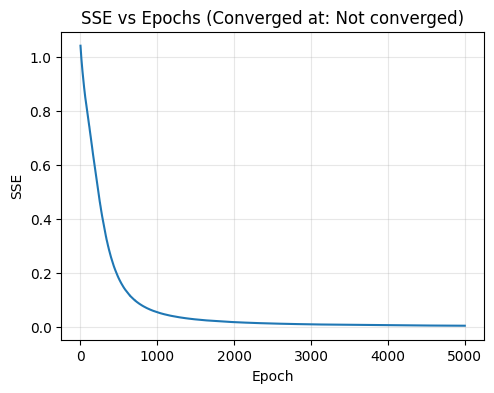

In [19]:
epochs_axis = np.arange(1, len(Losses) + 1)
sse_values = np.array(Losses) * len(X)  # SSE = MSE * number of samples
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_axis, sse_values, color="tab:blue")
plt.xlabel("Epoch")
plt.ylabel("SSE")
title_epoch = len(Losses) if Converged else "Not converged"
plt.title(f"SSE vs Epochs (Converged at: {title_epoch})")
plt.grid(True, alpha=0.3)


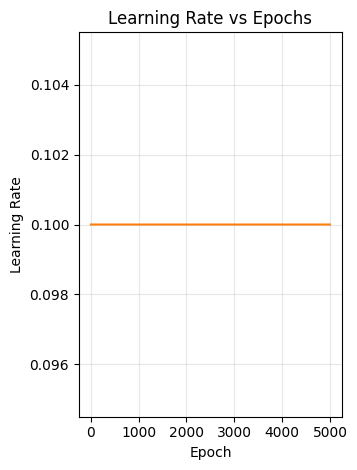

In [20]:
plt.subplot(1, 2, 2)
plt.plot(epochs_axis, Learning_rates, color="tab:orange")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate vs Epochs")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# now same thing with momentum
model_m = keras.Sequential([
    Dense(8, activation="relu", input_shape=(2,)),
    Dense(1, activation="sigmoid")
])

opt_m = keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model_m.compile(optimizer=opt_m, loss="mse")

In [22]:
Converged_m = False
Target_loss_m = 0.001
Losses_m = []
Learning_rates_m = []

max_epochs_m = 5000
epoch_m = 0
check_every_m = 10

while (not Converged_m) and (epoch_m < max_epochs_m):
    lr_cb_m = LRCallback()
    hist_m = model_m.fit(
        X, y,
        epochs=min(check_every_m, max_epochs_m - epoch_m),
        verbose=0,
        callbacks=[lr_cb_m]
    )

    chunk_losses_m = hist_m.history["loss"]
    Losses_m.extend(chunk_losses_m)

    if lr_cb_m.learning_rates:
        Learning_rates_m.extend(lr_cb_m.learning_rates)
    else:
        current_lr_m = float(tf.keras.backend.get_value(model_m.optimizer.learning_rate))
        Learning_rates_m.extend([current_lr_m] * len(chunk_losses_m))

    epoch_m += len(chunk_losses_m)
    Converged_m = Losses_m[-1] <= Target_loss_m

print(f"Converged={Converged_m}")
print(f"Target_loss={Target_loss_m}")
print(f"Final loss={Losses_m[-1]:.6f}")
print(f"Epochs trained={epoch_m}")

Converged=True
Target_loss=0.001
Final loss=0.000979
Epochs trained=400


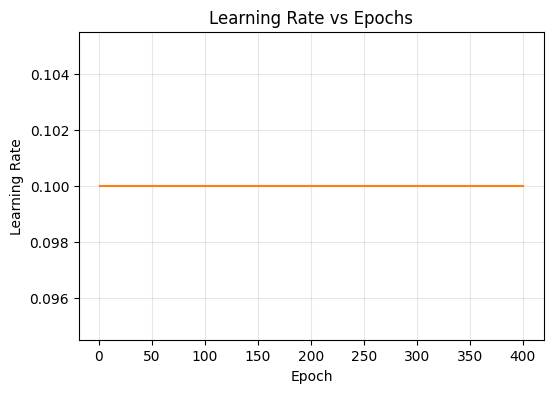

In [23]:
epochs_axis_m_lr = np.arange(1, len(Learning_rates_m) + 1)
plt.figure(figsize=(6, 4))
plt.plot(epochs_axis_m_lr, Learning_rates_m, color="tab:orange")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate vs Epochs")
plt.grid(True, alpha=0.3)
plt.show()

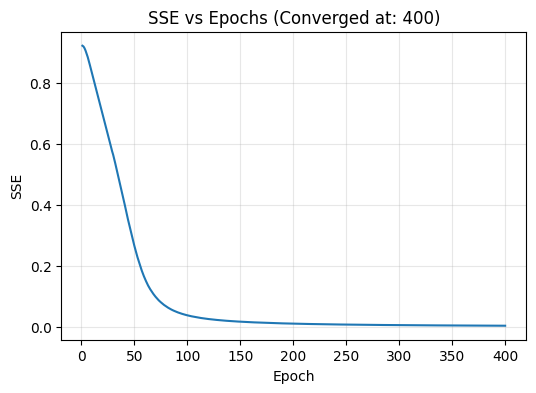

In [24]:
epochs_axis_m = np.arange(1, len(Losses_m) + 1)
sse_values_m = np.array(Losses_m) * len(X)
plt.figure(figsize=(6, 4))
plt.plot(epochs_axis_m, sse_values_m, color="tab:blue")
plt.xlabel("Epoch")
plt.ylabel("SSE")
title_epoch_m = len(Losses_m) if Converged_m else "Not converged"
plt.title(f"SSE vs Epochs (Converged at: {title_epoch_m})")
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
# adaptive lr only
model_a = keras.Sequential([
    Dense(8, activation="relu", input_shape=(2,)),
    Dense(1, activation="sigmoid")
])

opt_a = keras.optimizers.SGD(learning_rate=0.1)
model_a.compile(optimizer=opt_a, loss="mse")


def set_learning_rate(optimizer, new_lr):
    # tiny helper so keras does not complain about lr types
    try:
        optimizer.learning_rate.assign(new_lr)
    except Exception:
        optimizer.learning_rate = new_lr

In [28]:
Converged_a = False
Target_loss_a = 0.001
Losses_a = []
Learning_rates_a = []

max_epochs_a = 5000
epoch_a = 0
check_every_a = 5
prev_sse_a = None

while (not Converged_a) and (epoch_a < max_epochs_a):
    lr_cb_a = LRCallback()
    hist_a = model_a.fit(
        X, y,
        epochs=min(check_every_a, max_epochs_a - epoch_a),
        verbose=0,
        callbacks=[lr_cb_a]
    )

    chunk_losses_a = hist_a.history["loss"]
    Losses_a.extend(chunk_losses_a)

    if lr_cb_a.learning_rates:
        Learning_rates_a.extend(lr_cb_a.learning_rates)
    else:
        current_lr_a = float(tf.keras.backend.get_value(model_a.optimizer.learning_rate))
        Learning_rates_a.extend([current_lr_a] * len(chunk_losses_a))

    current_sse_a = Losses_a[-1] * len(X)

    if prev_sse_a is not None:
        current_lr_a = float(tf.keras.backend.get_value(model_a.optimizer.learning_rate))
        if current_sse_a > 1.04 * prev_sse_a:
            new_lr_a = current_lr_a * 0.7
        elif current_sse_a < prev_sse_a:
            new_lr_a = current_lr_a * 1.05
        else:
            new_lr_a = current_lr_a
        set_learning_rate(model_a.optimizer, new_lr_a)

    prev_sse_a = current_sse_a
    epoch_a += len(chunk_losses_a)
    Converged_a = Losses_a[-1] <= Target_loss_a

print(f"Converged={Converged_a}")
print(f"Target_loss={Target_loss_a}")
print(f"Final loss={Losses_a[-1]:.6f}")
print(f"Epochs trained={epoch_a}")

Converged=True
Target_loss=0.001
Final loss=0.000971
Epochs trained=395


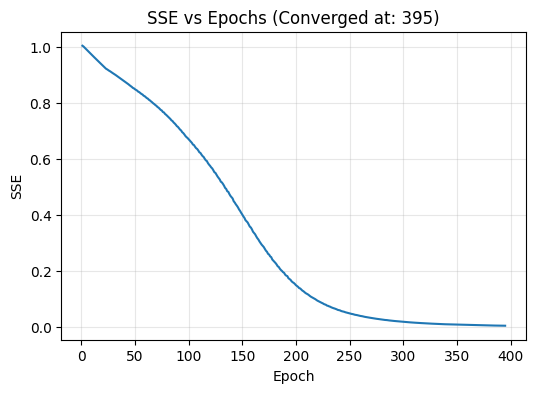

In [29]:
epochs_axis_a = np.arange(1, len(Losses_a) + 1)
sse_values_a = np.array(Losses_a) * len(X)
plt.figure(figsize=(6, 4))
plt.plot(epochs_axis_a, sse_values_a, color="tab:blue")
plt.xlabel("Epoch")
plt.ylabel("SSE")
title_epoch_a = len(Losses_a) if Converged_a else "Not converged"
plt.title(f"SSE vs Epochs (Converged at: {title_epoch_a})")
plt.grid(True, alpha=0.3)
plt.show()

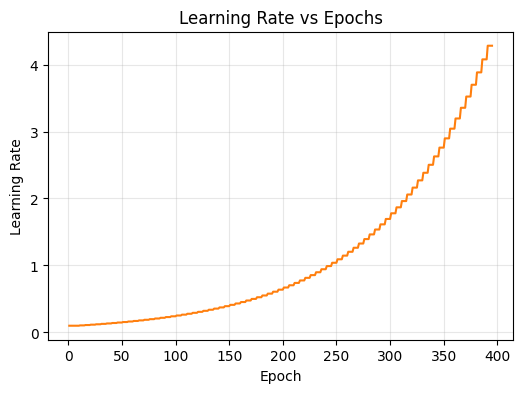

In [30]:
epochs_axis_a_lr = np.arange(1, len(Learning_rates_a) + 1)
plt.figure(figsize=(6, 4))
plt.plot(epochs_axis_a_lr, Learning_rates_a, color="tab:orange")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate vs Epochs")
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
# adaptive lr + momentum
model_am = keras.Sequential([
    Dense(8, activation="relu", input_shape=(2,)),
    Dense(1, activation="sigmoid")
])

opt_am = keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model_am.compile(optimizer=opt_am, loss="mse")

In [32]:
Converged_am = False
Target_loss_am = 0.001
Losses_am = []
Learning_rates_am = []

max_epochs_am = 5000
epoch_am = 0
check_every_am = 5
prev_sse_am = None

while (not Converged_am) and (epoch_am < max_epochs_am):
    lr_cb_am = LRCallback()
    hist_am = model_am.fit(
        X, y,
        epochs=min(check_every_am, max_epochs_am - epoch_am),
        verbose=0,
        callbacks=[lr_cb_am]
    )

    chunk_losses_am = hist_am.history["loss"]
    Losses_am.extend(chunk_losses_am)

    if lr_cb_am.learning_rates:
        Learning_rates_am.extend(lr_cb_am.learning_rates)
    else:
        current_lr_am = float(tf.keras.backend.get_value(model_am.optimizer.learning_rate))
        Learning_rates_am.extend([current_lr_am] * len(chunk_losses_am))

    current_sse_am = Losses_am[-1] * len(X)

    if prev_sse_am is not None:
        current_lr_am = float(tf.keras.backend.get_value(model_am.optimizer.learning_rate))
        if current_sse_am > 1.04 * prev_sse_am:
            new_lr_am = current_lr_am * 0.7
        elif current_sse_am < prev_sse_am:
            new_lr_am = current_lr_am * 1.05
        else:
            new_lr_am = current_lr_am
        set_learning_rate(model_am.optimizer, new_lr_am)

    prev_sse_am = current_sse_am
    epoch_am += len(chunk_losses_am)
    Converged_am = Losses_am[-1] <= Target_loss_am

print(f"Converged={Converged_am}")
print(f"Target_loss={Target_loss_am}")
print(f"Final loss={Losses_am[-1]:.6f}")
print(f"Epochs trained={epoch_am}")

Converged=True
Target_loss=0.001
Final loss=0.000974
Epochs trained=220


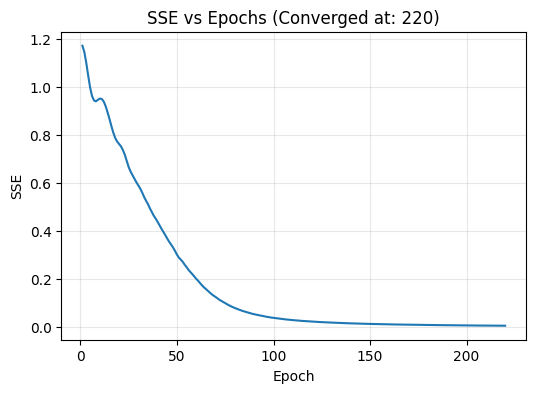

In [33]:
epochs_axis_am = np.arange(1, len(Losses_am) + 1)
sse_values_am = np.array(Losses_am) * len(X)
plt.figure(figsize=(6, 4))
plt.plot(epochs_axis_am, sse_values_am, color="tab:blue")
plt.xlabel("Epoch")
plt.ylabel("SSE")
title_epoch_am = len(Losses_am) if Converged_am else "Not converged"
plt.title(f"SSE vs Epochs (Converged at: {title_epoch_am})")
plt.grid(True, alpha=0.3)
plt.show()

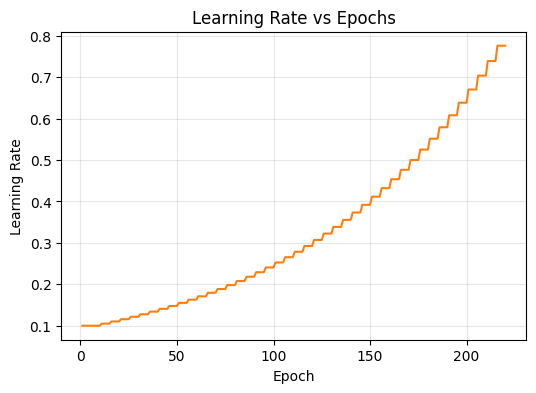

In [34]:
epochs_axis_am_lr = np.arange(1, len(Learning_rates_am) + 1)
plt.figure(figsize=(6, 4))
plt.plot(epochs_axis_am_lr, Learning_rates_am, color="tab:orange")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate vs Epochs")
plt.grid(True, alpha=0.3)
plt.show()

### How does a multilayer neural network solve the XOR problem?
The problem is not linearly separable, so a single layer can not solve it. A multilayer neural network can solve the XOR problem by introducing non-linearity through activation functions in the hidden layers.
### In a backpropagation neural network, why are the middle layers called “hidden”?
The middle layers are called "hidden" because they are not directly exposed to the input or output. They are "hidden" from the data and only interact with the input and output through the other layers. 

### How are hyperparameters different from model parameters?
Hyperparameters are set before training and control the learning process (e.g., learning rate, batch size), while model parameters are learned during training (e.g., weights and biases).

### Explain the concept of accelerated learning in backpropagation.
Accelerated learning in backpropagation refers to techniques that speed up the convergence of the training process. This can be achieved through methods like momentum, which helps to navigate the loss landscape more efficiently, or adaptive learning rates, which adjust the learning rate based on the progress of training.

### What are two heuristics applied in adaptive learning rate?
1. **Learning Rate Decay**: Gradually reducing the learning rate over time to allow the model to fine-tune its parameters as it gets closer to the optimal solution.
2. **Adaptive Learning Rate Methods**: Algorithms like AdaGrad, RMSProp, and Adam adjust the learning rate for each parameter based on the historical gradients, allowing for faster convergence and better performance.